# GenAI_194 - W6D4 - MP

## Downloading the dataset

In [1]:
!wget https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip

--2026-04-27 12:32:58--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip [following]
--2026-04-27 12:32:58--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 856265363 (817M) [application/zip]
Saving to: ‘Dogs vs Cats.zip’

Dogs vs Cats.zip    100%[===================>] 8

In [2]:
# Unzip the file
!unzip "/content/Dogs vs Cats.zip"

Streaming output truncated to the last 5000 lines.
  inflating: train/train/dog.5499.jpg  
  inflating: train/train/dog.55.jpg  
  inflating: train/train/dog.550.jpg  
  inflating: train/train/dog.5500.jpg  
  inflating: train/train/dog.5501.jpg  
  inflating: train/train/dog.5502.jpg  
  inflating: train/train/dog.5503.jpg  
  inflating: train/train/dog.5504.jpg  
  inflating: train/train/dog.5505.jpg  
  inflating: train/train/dog.5506.jpg  
  inflating: train/train/dog.5507.jpg  
  inflating: train/train/dog.5508.jpg  
  inflating: train/train/dog.5509.jpg  
  inflating: train/train/dog.551.jpg  
  inflating: train/train/dog.5510.jpg  
  inflating: train/train/dog.5511.jpg  
  inflating: train/train/dog.5512.jpg  
  inflating: train/train/dog.5513.jpg  
  inflating: train/train/dog.5514.jpg  
  inflating: train/train/dog.5515.jpg  
  inflating: train/train/dog.5516.jpg  
  inflating: train/train/dog.5517.jpg  
  inflating: train/train/dog.5518.jpg  
  inflating: train/train/dog.5519

## Creating Generators

In [3]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [4]:
# Set fixed seed
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [5]:
# Paths - change if needed
train_dir = "/content/train/train"
test_dir = "/content/test/test"

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 128

In [14]:
# Build DataFrames from folders
def build_df_from_folder(folder, labeled=True):
    files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
        files.extend(glob(f"{folder}/**/{ext}", recursive=True))

    if not files:
        raise FileNotFoundError(f"No images found under {folder}")

    rows = []

    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()

            if parent in {"cat", "cats"}:
                label = "cat"
            elif parent in {"dog", "dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name):
                    label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name):
                    label = "dog"
                else:
                    continue

            rows.append({"filepath": f, "label": label})

        else:
            rows.append({"filepath": f})

    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full = build_df_from_folder(test_dir, labeled=False)

print(df_train_full.head())
print(df_train_full["label"].value_counts())
print(df_test_full.head())

                             filepath label
0  /content/train/train/dog.10324.jpg   dog
1  /content/train/train/cat.10024.jpg   cat
2   /content/train/train/cat.6369.jpg   cat
3   /content/train/train/cat.1920.jpg   cat
4  /content/train/train/cat.11797.jpg   cat
label
dog    12500
cat    12500
Name: count, dtype: int64
                       filepath
0    /content/test/test/110.jpg
1  /content/test/test/10542.jpg
2  /content/test/test/10558.jpg
3   /content/test/test/8943.jpg
4   /content/test/test/4174.jpg


In [ ]:
# Train_test_split

In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Train / validation split
df_tr, df_val = train_test_split(
    df_train_full,
    test_size=0.2,
    stratify=df_train_full["label"],
    random_state=SEED
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=True,
    seed=SEED,
    validate_filenames=False
)

val_flow = val_gen.flow_from_dataframe(
    df_val,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=False,
    validate_filenames=False
)

test_flow = test_gen.flow_from_dataframe(
    df_test_full,
    x_col="filepath",
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    batch_size=batch_size,
    shuffle=False,
    validate_filenames=False
)

print({
    "train": train_flow.samples,
    "val": val_flow.samples,
    "test": test_flow.samples,
    "class_indices": train_flow.class_indices
})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


# Inspect the data

In [16]:
import pandas as pd

print(df_train_full["label"].value_counts())

label
dog    12500
cat    12500
Name: count, dtype: int64


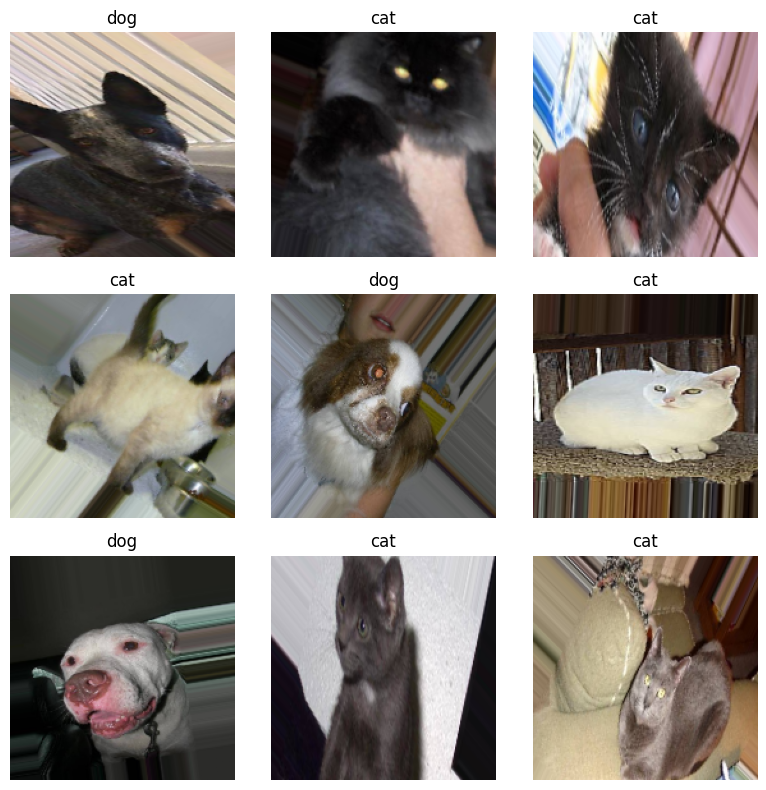

In [17]:
import matplotlib.pyplot as plt

images, labels = next(train_flow)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("dog" if labels[i] == 1 else "cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Define the model architecture

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 174, 174, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 87, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 85, 85, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Choose the optimization setup
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

I used the Adam optimizer because it usually provides fast and stable convergence. The learning rate was set to 0.001, which is a common starting point for CNN models. The batch size was 128, which helps train faster but still depends on available memory. EarlyStopping was used to monitor validation loss and stop training when the model stopped improving. ReduceLROnPlateau was added to reduce the learning rate when validation loss stopped improving.

In [21]:
# Train the model
history = model.fit(train_flow, validation_data=val_flow, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.5987 - loss: 0.6595 - val_accuracy: 0.6764 - val_loss: 0.5839 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.6697 - loss: 0.6031 - val_accuracy: 0.7042 - val_loss: 0.5604 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.6957 - loss: 0.5824 - val_accuracy: 0.7190 - val_loss: 0.5395 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.7145 - loss: 0.5559 - val_accuracy: 0.7396 - val_loss: 0.5090 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7176 - loss: 0.5470 - val_accuracy: 0.7636 - val_loss: 0.4949 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7326 - loss: 0.5285 - val_accuracy: 0.7886 - val_loss: 0.4520 - learning_rate: 0.0010
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.7428 - loss: 0.

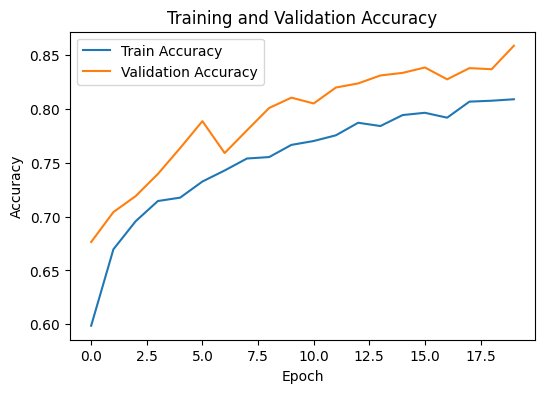

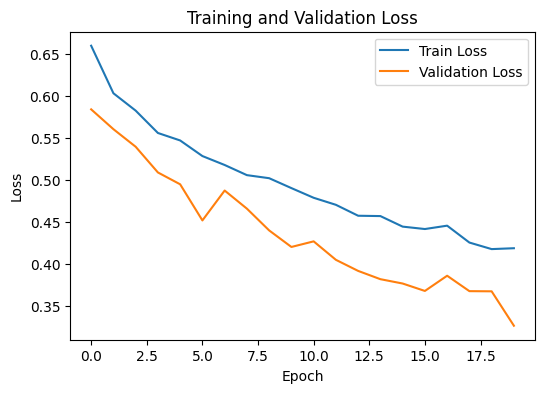

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [23]:
# Evaluate on validation data
val_loss, val_accuracy = model.evaluate(val_flow)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 253ms/step - accuracy: 0.8586 - loss: 0.3270
Validation Loss: 0.3269694447517395
Validation Accuracy: 0.8586000204086304


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

val_flow.reset()

probabilities = model.predict(val_flow)
predictions = (probabilities > 0.5).astype(int).reshape(-1)

true_labels = val_flow.classes

print("Class indices:", val_flow.class_indices)

cm = confusion_matrix(true_labels, predictions)
print(cm)

print(classification_report(true_labels, predictions, target_names=list(val_flow.class_indices.keys())))

40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step
Class indices: {'cat': 0, 'dog': 1}
[[2104  396]
 [ 311 2189]]
              precision    recall  f1-score   support

         cat       0.87      0.84      0.86      2500
         dog       0.85      0.88      0.86      2500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



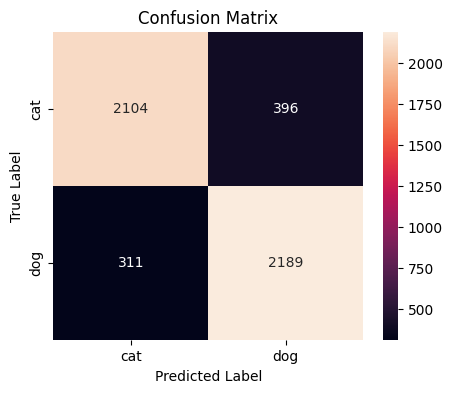

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=list(val_flow.class_indices.keys()),
    yticklabels=list(val_flow.class_indices.keys())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The model was evaluated on the validation set using validation loss, validation accuracy, a confusion matrix, precision, and recall. The confusion matrix shows how many cats and dogs were classified correctly and incorrectly. Precision and recall provide more detailed information than accuracy because they show the model performance for each class separately.

In [26]:
# Run inference on the unlabeled test set
test_flow.reset()

test_probs = model.predict(test_flow).reshape(-1)

test_predictions = np.where(test_probs > 0.5, "dog", "cat")

submission = pd.DataFrame({
    "filepath": df_test_full["filepath"].values,
    "prob_dog": test_probs,
    "pred_label": test_predictions
})

submission.head()

98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 273ms/step


,filepath,prob_dog,pred_label
0,/content/test/test/110.jpg,0.998982,dog
1,/content/test/test/10542.jpg,0.433253,cat
2,/content/test/test/10558.jpg,0.748968,dog
3,/content/test/test/8943.jpg,0.032430,cat
4,/content/test/test/4174.jpg,0.996504,dog


In [27]:
submission.to_csv("cats_dogs_predictions.csv", index=False)
print("Saved cats_dogs_predictions.csv")

Saved cats_dogs_predictions.csv


# Model without augmentation


In [28]:
baseline_gen = ImageDataGenerator(rescale=1./255)

baseline_train_flow = baseline_gen.flow_from_dataframe(
    df_tr,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=True,
    seed=SEED
)

model_baseline = tf.keras.models.clone_model(model)
model_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_baseline = model_baseline.fit(baseline_train_flow, validation_data=val_flow, epochs=20, callbacks=[early_stop])

Found 20000 validated image filenames belonging to 2 classes.
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 353ms/step - accuracy: 0.6461 - loss: 0.6295 - val_accuracy: 0.7310 - val_loss: 0.5338
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 331ms/step - accuracy: 0.7492 - loss: 0.5122 - val_accuracy: 0.7544 - val_loss: 0.4965
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 329ms/step - accuracy: 0.7881 - loss: 0.4548 - val_accuracy: 0.7912 - val_loss: 0.4451
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 335ms/step - accuracy: 0.8187 - loss: 0.3993 - val_accuracy: 0.8112 - val_loss: 0.4087
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 332ms/step - accuracy: 0.8467 - loss: 0.3535 - val_accuracy: 0.8222 - val_loss: 0.4216


The model did not train for all 20 epochs because EarlyStopping was used. Training stopped early when the validation loss stopped improving for several epochs. This prevents overfitting and ensures that the best model is retained.

In [29]:
model.save("cats_dogs_cnn_model.h5")

In [31]:
model.save("cats_dogs_cnn_model.keras")

The model was saved using the Keras format to ensure compatibility with modern TensorFlow versions and allow future reuse without retraining.
The trained model was saved to disk to allow future use without retraining. Saving the model ensures reproducibility and allows it to be used later for inference or further fine-tuning.